In [1]:
import numpy as np
import numpy.random as nr
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [22]:
N=2000
SNR_Db= 5
SNR=10**(SNR_Db/10)

SNR

3.1622776601683795

In [29]:
bits = np.random.randint(0,2,N)
tx =np.sqrt(SNR) * (2*bits - 1)

In [28]:
# noise
noise=(nr.randn(N)+1j*nr.randn(N))/np.sqrt(2)
noise

array([ 1.25473982-0.97882695j, -0.85732851-0.37128252j,
        0.26464928+0.22851702j, ..., -0.15424315-0.55603315j,
        0.10984841+0.88606947j, -1.50785528+0.04816013j])

In [30]:
# recieve sig
rx=tx+noise


In [35]:
x=np.column_stack((np.real(rx),-np.imag(rx)))
y = bits
x

array([[-0.52353959,  0.97882695],
       [-2.63560792,  0.37128252],
       [-1.51363013, -0.22851702],
       ...,
       [ 1.62403626,  0.55603315],
       [ 1.88812782, -0.88606947],
       [ 0.27042413, -0.04816013]])

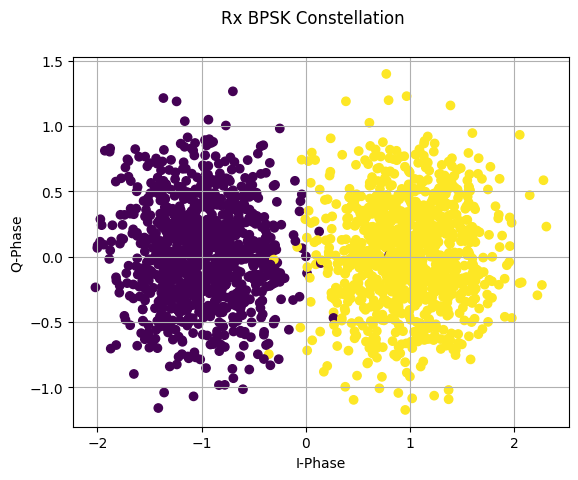

In [36]:
plt.figure(1);
plt.scatter(x[:, 0]/np.sqrt(SNR), x[:, 1]/np.sqrt(SNR), c = y)
plt.suptitle('Rx BPSK Constellation')
plt.xlabel('I-Phase')
plt.ylabel('Q-Phase')
plt.grid(1,which='both')
plt.axis('tight')
plt.show()

In [38]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


Confusion matrix of BPSK detection is 
 [[202   4]
 [  0 194]] 

Accuracy score of BPSK detection is 99.0 %



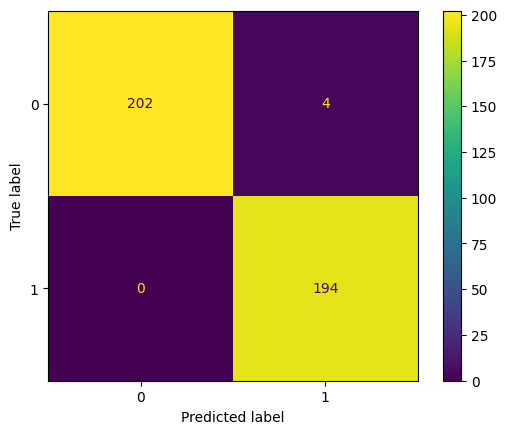

In [39]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

cmat = confusion_matrix(y_test, y_pred)
print('Confusion matrix of BPSK detection is \n',cmat,'\n')

disp = ConfusionMatrixDisplay(confusion_matrix=cmat)
disp.plot()

LRscore = accuracy_score(y_test, y_pred)
print('Accuracy score of BPSK detection is',100*LRscore,'%\n')




In [55]:

prob_1 = model.predict_proba(x)[:,1]

cf=model.coef_; #verify that 2nd feature doesnt participate
b  = model.intercept_[0]

xplot=np.arange(-0.1,0.1,0.01);
yplot=-(cf[0,0]*xplot+model.intercept_)/cf[0,1];



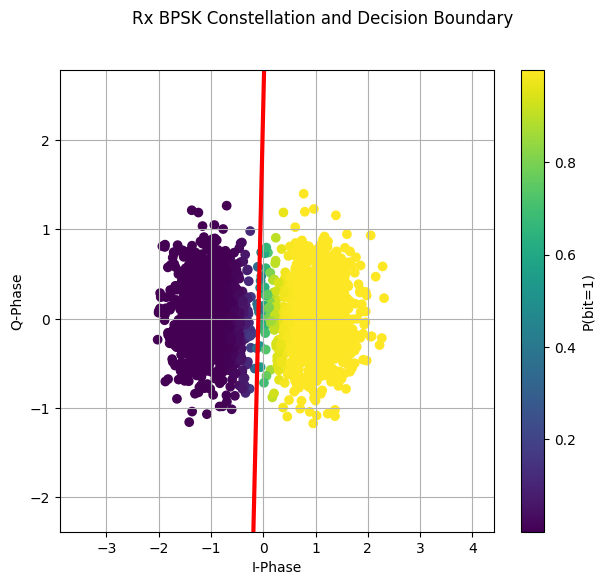

In [59]:
plt.figure(figsize=(7,6))
plt.scatter(x[:, 0]/np.sqrt(SNR), x[:, 1]/np.sqrt(SNR), c = prob_1)
if abs(cf[0][1]) < 1e-5:          # Q feature unused → vertical line
    x_boundary = -b/cf[0][0]
    plt.axvline(x_boundary, color='red', linewidth=3)
else:
    xplot = np.linspace(x[:,0].min(), x[:,0].max(), 200)
    yplot = -(cf[0][0]*xplot + b)/cf[0][1]
    plt.plot(xplot, yplot, 'r', linewidth=3)
plt.plot(xplot,yplot,'r')
plt.suptitle('Rx BPSK Constellation and Decision Boundary')
plt.xlabel('I-Phase')
plt.ylabel('Q-Phase')
plt.grid(True)

plt.xlim(x[:,0].min()-0.3, x[:,0].max()+0.3)
plt.ylim(x[:,1].min()-0.3, x[:,1].max()+0.3)

plt.colorbar(label="P(bit=1)")
plt.show()
